In [89]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/finance_data.csv")

df.head(20)



,Date,Name,Salary,Bonus,Department,Age
0,01/29/2023,Diana,,NaN,Finance,63
1,06/16/2023,,NaN,"$4,971",,35
2,12/31/2023,Hank,,NaN,Sales,37
3,06/22/2023,Jack,"$85,353",9554 USD,Finance,55
4,08/30/2023,Frank,NaN,none,HR,71
5,09/29/2023,Diana,"$80,435",9110 USD,IT,23
6,01/31/2023,Diana,NaN,none,none,150
7,01/25/2023,Charlie,"$78,627",4587 USD,HR,25
8,11/19/2023,Grace,NaN,7279 USD,IT,42
9,10/31/2023,Charlie,,4168 USD,HR,36


In [66]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        50 non-null     object
 1   Name        50 non-null     object
 2   Salary      26 non-null     object
 3   Bonus       38 non-null     object
 4   Department  49 non-null     object
 5   Age         50 non-null     int64 
dtypes: int64(1), object(5)
memory usage: 2.5+ KB
None


In [67]:
print(df.isna().sum())

Date           0
Name           0
Salary        24
Bonus         12
Department     1
Age            0
dtype: int64


In [88]:

def df_cleaned(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        df_clean.replace(['none', 'None', ' '], np.nan, inplace=True)
        df_clean["Salary"].replace(["$", "USD", " USD"], '', inplace=True) 
        df_clean[col] = df_clean[col].fillna(method='ffill').fillna(method='bfill')
        
    
    return df_clean


# Apply cleaning function
cleaned_data = df_cleaned(df)

# View cleaned data
cleaned_data.head()


C:\Users\HP\AppData\Local\Temp\ipykernel_14348\2197021833.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["Salary"].replace(["$", "USD", " USD"], '', inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_14348\2197021833.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method='ffill').fillna(method='bfill')


,Date,Name,Salary,Bonus,Department,Age
0,01/29/2023,Diana,"$85,353","$4,971",Finance,63
1,06/16/2023,Diana,"$85,353","$4,971",Finance,35
2,12/31/2023,Hank,"$85,353","$4,971",Sales,37
3,06/22/2023,Jack,"$85,353",9554 USD,Finance,55
4,08/30/2023,Frank,"$85,353",9554 USD,HR,71


In [78]:
cleaned_data.isna().sum()

Date          0
Name          0
Salary        0
Bonus         0
Department    0
Age           0
dtype: int64

In [ ]:
print()

In [30]:
## Importing libraries and reading the data
import pandas as pd
import numpy as np
finance = pd.read_csv("data/finance_data.csv")

#Displaying the top 20 rows
finance.head(6)

,Date,Name,Salary,Bonus,Department,Age
0,01/29/2023,Diana,,NaN,Finance,63
1,06/16/2023,,NaN,"$4,971",,35
2,12/31/2023,Hank,,NaN,Sales,37
3,06/22/2023,Jack,"$85,353",9554 USD,Finance,55
4,08/30/2023,Frank,NaN,none,HR,71
5,09/29/2023,Diana,"$80,435",9110 USD,IT,23


In [33]:
## Adding Year, Month, Quarter, Week based on date column
finance["Date"] = pd.to_datetime(finance["Date"])

#Adding year column based on date
finance["Year"] = finance["Date"].dt.year

#Adding the quarter column
finance["Quarter"] = finance["Date"].dt.quarter

# Adding month column
finance["Month"] =  finance["Date"].dt.month
finance["Week"] = finance["Date"].dt.isocalendar().week

finance.head(6)

,Date,Name,Salary,Bonus,Department,Age,Year,Quarter,Month,Week
0,2023-01-29,Diana,,NaN,Finance,63,2023,1,1,4
1,2023-06-16,,NaN,"$4,971",,35,2023,2,6,24
2,2023-12-31,Hank,,NaN,Sales,37,2023,4,12,52
3,2023-06-22,Jack,"$85,353",9554 USD,Finance,55,2023,2,6,25
4,2023-08-30,Frank,NaN,none,HR,71,2023,3,8,35
5,2023-09-29,Diana,"$80,435",9110 USD,IT,23,2023,3,9,39


<Axes: xlabel='Quarter'>

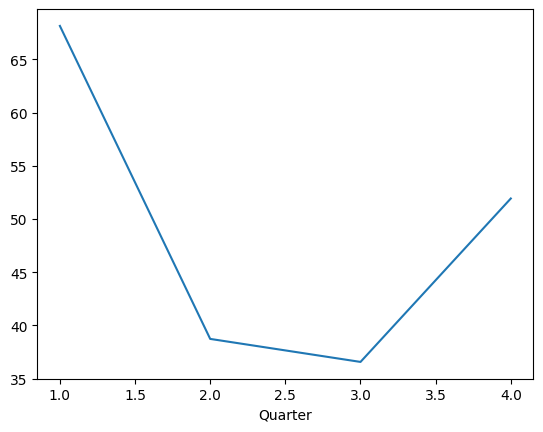

In [41]:
# finance.plot(kind='line', x='Quarter', y='Age')

finance.groupby("Quarter")["Age"].mean().plot(kind='line') # mean of Age for each Quarter group

In [79]:
## Dealing with outliers on Age column/feature/Attribute
## Using IQR method
q1 = finance["Age"].quantile(0.25)
q3 = finance["Age"].quantile(0.75)
IQR = q3 - q1
IQR
#Upper bound
up = q3 + 0.5*IQR
#Lower bound
low = q1 - 0.5 *IQR

In [80]:
## Remove outliers
finance_clean = finance[(finance["Age"] > low) & (finance["Age"] < up)]
finance_clean["Age"].describe()

count    42.000000
mean     49.190476
std      15.484435
min      23.000000
25%      36.250000
50%      50.500000
75%      60.250000
max      76.000000
Name: Age, dtype: float64